# Capstone Project: Build PCA from Scratch

In this capstone project, we bring together the core mathematical concepts from the book to implement Principal Component Analysis (PCA) from scratch:

- **Linear Algebra**: Matrix operations, eigendecomposition
- **SVD**: Singular Value Decomposition for dimensionality reduction
- **Geometric Intuition**: Understanding projections and variance

## Learning Objectives

By the end of this notebook, you will be able to:

1. Implement PCA using eigendecomposition of the covariance matrix
2. Implement PCA using SVD (the more numerically stable approach)
3. Understand the relationship between eigenvalues and explained variance
4. Visualize high-dimensional data in 2D using PCA
5. Reconstruct data from principal components
6. Build a complete, sklearn-compatible PCA class

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA as SklearnPCA
from sklearn.preprocessing import StandardScaler

# Configure matplotlib
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 12

# Set random seed for reproducibility
np.random.seed(42)

## Load MNIST Data

We'll use sklearn's `load_digits` dataset - a simplified version of MNIST with 8x8 pixel images of handwritten digits (0-9). This gives us 64 features per sample, making it perfect for demonstrating dimensionality reduction.

In [2]:
# Load the digits dataset
digits = load_digits()
X = digits.data  # Shape: (n_samples, 64)
y = digits.target  # Digit labels 0-9

print(f"Dataset shape: {X.shape}")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features (pixels): {X.shape[1]}")
print(f"Image dimensions: 8 x 8 = 64 pixels")
print(f"Unique labels: {np.unique(y)}")
print(f"Pixel value range: [{X.min()}, {X.max()}]")

Dataset shape: (1797, 64)
Number of samples: 1797
Number of features (pixels): 64
Image dimensions: 8 x 8 = 64 pixels
Unique labels: [0 1 2 3 4 5 6 7 8 9]
Pixel value range: [0.0, 16.0]


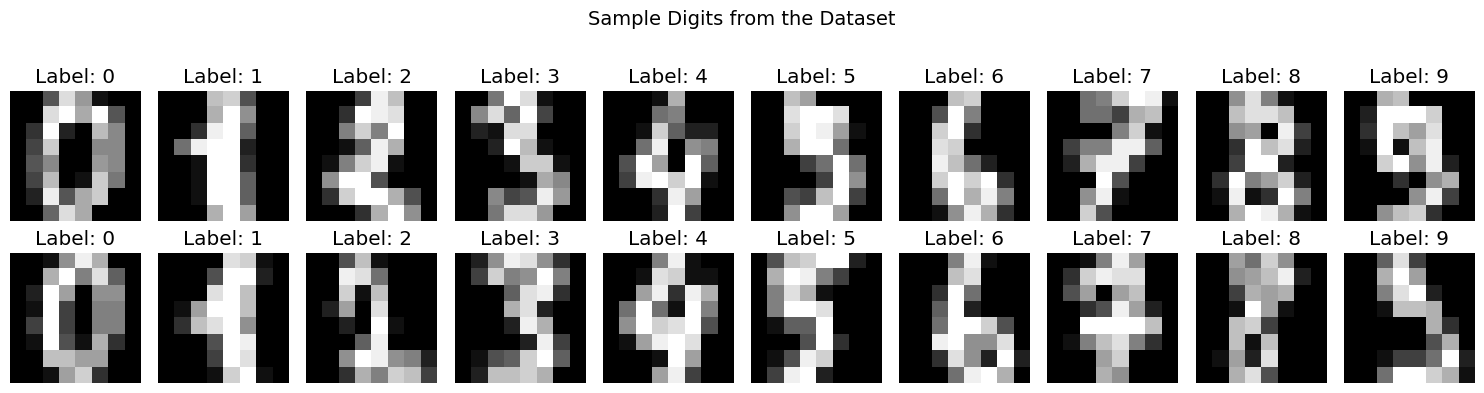

In [3]:
# Visualize some sample digits
fig, axes = plt.subplots(2, 10, figsize=(15, 4))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f'Label: {y[i]}')
    ax.axis('off')

plt.suptitle('Sample Digits from the Dataset', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Step 1: Center the Data

The first step in PCA is to center the data by subtracting the mean of each feature. This is crucial because:

1. **PCA finds directions of maximum variance** - without centering, the first principal component might just point toward the mean
2. **Covariance matrix requires centered data** - the formula $C = \frac{1}{n-1}X^TX$ assumes zero-mean data
3. **Geometric interpretation** - centering moves the data cloud to the origin, making principal components pass through the center

$$X_{centered} = X - \mu$$

where $\mu$ is the mean of each feature (column).

In [4]:
# Step 1: Center the data
# Compute the mean of each feature (pixel)
mean = np.mean(X, axis=0)

print(f"Mean vector shape: {mean.shape}")
print(f"Mean values range: [{mean.min():.2f}, {mean.max():.2f}]")

# Center the data
X_centered = X - mean

# Verify centering worked
print(f"\nAfter centering:")
print(f"Mean of centered data: {np.mean(X_centered, axis=0).mean():.2e} (should be ~0)")

Mean vector shape: (64,)
Mean values range: [0.00, 12.09]

After centering:
Mean of centered data: -2.50e-17 (should be ~0)


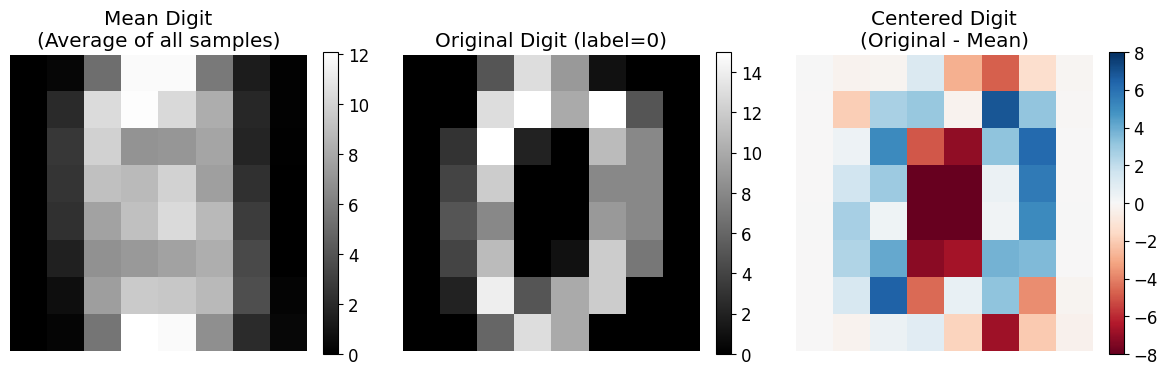

Note: Centered data has positive (red) and negative (blue) values


In [5]:
# Visualize the mean digit (average of all digits)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Mean digit
ax = axes[0]
im = ax.imshow(mean.reshape(8, 8), cmap='gray')
ax.set_title('Mean Digit\n(Average of all samples)')
ax.axis('off')
plt.colorbar(im, ax=ax, fraction=0.046)

# Sample original digit
ax = axes[1]
sample_idx = 0
im = ax.imshow(X[sample_idx].reshape(8, 8), cmap='gray')
ax.set_title(f'Original Digit (label={y[sample_idx]})')
ax.axis('off')
plt.colorbar(im, ax=ax, fraction=0.046)

# Sample centered digit
ax = axes[2]
im = ax.imshow(X_centered[sample_idx].reshape(8, 8), cmap='RdBu', 
               vmin=-8, vmax=8)
ax.set_title('Centered Digit\n(Original - Mean)')
ax.axis('off')
plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

print("Note: Centered data has positive (red) and negative (blue) values")

## Step 2: Compute Covariance Matrix

The covariance matrix captures how features vary together. For centered data $X$ with $n$ samples and $d$ features:

$$C = \frac{1}{n-1} X^T X$$

The covariance matrix $C$ is:
- **Symmetric**: $C = C^T$
- **Positive semi-definite**: All eigenvalues are non-negative
- **Size**: $d \times d$ (64 x 64 for our digit data)

Each entry $C_{ij}$ measures how features $i$ and $j$ co-vary.

In [6]:
# Step 2: Compute the covariance matrix manually
n_samples = X_centered.shape[0]
cov_matrix = (X_centered.T @ X_centered) / (n_samples - 1)

print(f"Covariance matrix shape: {cov_matrix.shape}")
print(f"Is symmetric: {np.allclose(cov_matrix, cov_matrix.T)}")

# Verify against numpy's built-in function
cov_numpy = np.cov(X_centered, rowvar=False)
print(f"Matches np.cov: {np.allclose(cov_matrix, cov_numpy)}")

Covariance matrix shape: (64, 64)
Is symmetric: True
Matches np.cov: True


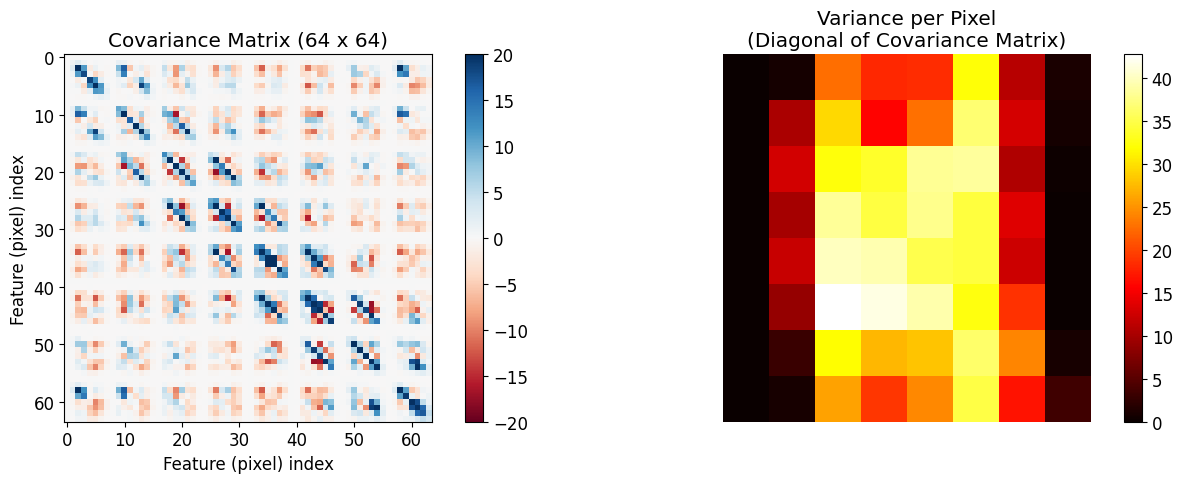

High variance pixels (bright in right plot) contain more discriminative information


In [7]:
# Visualize the covariance matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full covariance matrix
ax = axes[0]
im = ax.imshow(cov_matrix, cmap='RdBu', vmin=-20, vmax=20)
ax.set_title('Covariance Matrix (64 x 64)')
ax.set_xlabel('Feature (pixel) index')
ax.set_ylabel('Feature (pixel) index')
plt.colorbar(im, ax=ax)

# Diagonal (variance of each pixel)
ax = axes[1]
variance_per_pixel = np.diag(cov_matrix).reshape(8, 8)
im = ax.imshow(variance_per_pixel, cmap='hot')
ax.set_title('Variance per Pixel\n(Diagonal of Covariance Matrix)')
ax.axis('off')
plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

print("High variance pixels (bright in right plot) contain more discriminative information")

## Step 3: Eigendecomposition

The principal components are the **eigenvectors** of the covariance matrix, and the **eigenvalues** represent the variance captured by each component.

$$C \mathbf{v}_i = \lambda_i \mathbf{v}_i$$

Where:
- $\mathbf{v}_i$ is the $i$-th principal component (eigenvector)
- $\lambda_i$ is the variance explained by that component (eigenvalue)

We sort eigenvectors by decreasing eigenvalue to get components in order of importance.

In [8]:
# Step 3: Eigendecomposition of the covariance matrix
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Eigenvalues might be complex (with tiny imaginary parts due to numerical errors)
# For a symmetric matrix, they should be real
eigenvalues = np.real(eigenvalues)
eigenvectors = np.real(eigenvectors)

print(f"Eigenvalues shape: {eigenvalues.shape}")
print(f"Eigenvectors shape: {eigenvectors.shape}")
print(f"All eigenvalues non-negative: {np.all(eigenvalues >= -1e-10)}")

Eigenvalues shape: (64,)
Eigenvectors shape: (64, 64)
All eigenvalues non-negative: True


In [9]:
# Sort eigenvalues and eigenvectors in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues_sorted = eigenvalues[sorted_indices]
eigenvectors_sorted = eigenvectors[:, sorted_indices]

print("Top 10 eigenvalues (variance explained by each PC):")
for i in range(10):
    print(f"  PC{i+1}: {eigenvalues_sorted[i]:.2f}")

# These eigenvectors are our principal components
# Each column is a principal component
components_eig = eigenvectors_sorted.T  # Shape: (n_components, n_features)
print(f"\nPrincipal components shape: {components_eig.shape}")

Top 10 eigenvalues (variance explained by each PC):
  PC1: 179.01
  PC2: 163.72
  PC3: 141.79
  PC4: 101.10
  PC5: 69.51
  PC6: 59.11
  PC7: 51.88
  PC8: 44.02
  PC9: 40.31
  PC10: 37.01

Principal components shape: (64, 64)


In [10]:
# Verify the eigenvalue equation: C @ v = lambda * v
print("Verifying eigenvalue equation for first 5 components:")
for i in range(5):
    v = eigenvectors_sorted[:, i]
    lam = eigenvalues_sorted[i]
    
    lhs = cov_matrix @ v
    rhs = lam * v
    
    error = np.linalg.norm(lhs - rhs)
    print(f"  PC{i+1}: ||Cv - lambda*v|| = {error:.2e}")

Verifying eigenvalue equation for first 5 components:
  PC1: ||Cv - lambda*v|| = 2.73e-13
  PC2: ||Cv - lambda*v|| = 5.25e-13
  PC3: ||Cv - lambda*v|| = 3.23e-13
  PC4: ||Cv - lambda*v|| = 4.06e-13
  PC5: ||Cv - lambda*v|| = 2.09e-13


## Step 4: SVD Approach

An alternative (and often preferred) way to compute PCA is using Singular Value Decomposition directly on the centered data:

$$X_{centered} = U \Sigma V^T$$

The relationship to eigendecomposition:
- **Principal components**: Rows of $V^T$ (or columns of $V$)
- **Eigenvalues**: $\lambda_i = \frac{\sigma_i^2}{n-1}$ where $\sigma_i$ are singular values
- **Projected data**: $U \Sigma$ gives the data in PC space

SVD is preferred because:
1. More numerically stable
2. Works directly on data (no need to form covariance matrix)
3. More efficient for high-dimensional data with few samples

In [11]:
# Step 4: Compute PCA using SVD
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

print(f"U shape: {U.shape}")
print(f"S (singular values) shape: {S.shape}")
print(f"Vt shape: {Vt.shape}")

# Principal components from SVD
components_svd = Vt  # Rows are principal components

print(f"\nPrincipal components shape: {components_svd.shape}")

U shape: (1797, 64)
S (singular values) shape: (64,)
Vt shape: (64, 64)

Principal components shape: (64, 64)


In [12]:
# Verify equivalence between eigendecomposition and SVD approaches

# 1. Eigenvalues from SVD: lambda = sigma^2 / (n-1)
eigenvalues_from_svd = S**2 / (n_samples - 1)

print("Comparing eigenvalues from both methods (top 10):")
print("-" * 50)
print(f"{'Eigendecomp':>15} | {'SVD':>15} | {'Difference':>15}")
print("-" * 50)
for i in range(10):
    diff = abs(eigenvalues_sorted[i] - eigenvalues_from_svd[i])
    print(f"{eigenvalues_sorted[i]:>15.4f} | {eigenvalues_from_svd[i]:>15.4f} | {diff:>15.2e}")

Comparing eigenvalues from both methods (top 10):
--------------------------------------------------
    Eigendecomp |             SVD |      Difference
--------------------------------------------------
       179.0069 |        179.0069 |        0.00e+00
       163.7177 |        163.7177 |        2.27e-13
       141.7884 |        141.7884 |        2.27e-13
       101.1004 |        101.1004 |        3.98e-13
        69.5132 |         69.5132 |        2.13e-13
        59.1085 |         59.1085 |        4.62e-13
        51.8845 |         51.8845 |        3.55e-14
        44.0151 |         44.0151 |        0.00e+00
        40.3110 |         40.3110 |        0.00e+00
        37.0118 |         37.0118 |        1.35e-13


In [13]:
# 2. Compare principal components (may differ by sign)
print("\nComparing principal components (accounting for sign ambiguity):")
print("-" * 50)

for i in range(5):
    # Eigenvectors can differ by sign, so check both orientations
    pc_eig = components_eig[i]
    pc_svd = components_svd[i]
    
    # Check if they match (up to sign)
    same_sign = np.allclose(pc_eig, pc_svd, atol=1e-10)
    opposite_sign = np.allclose(pc_eig, -pc_svd, atol=1e-10)
    
    if same_sign:
        print(f"  PC{i+1}: Match (same sign)")
    elif opposite_sign:
        print(f"  PC{i+1}: Match (opposite sign)")
    else:
        # Compute cosine similarity
        cos_sim = abs(np.dot(pc_eig, pc_svd))
        print(f"  PC{i+1}: Cosine similarity = {cos_sim:.6f}")

print("\nNote: Sign ambiguity is expected - both v and -v are valid eigenvectors")


Comparing principal components (accounting for sign ambiguity):
--------------------------------------------------
  PC1: Match (same sign)
  PC2: Match (same sign)
  PC3: Match (same sign)
  PC4: Match (opposite sign)
  PC5: Match (same sign)

Note: Sign ambiguity is expected - both v and -v are valid eigenvectors


## Step 5: Project Data to 2D

Now we can project our 64-dimensional data onto the first 2 principal components to visualize it:

$$X_{projected} = X_{centered} \cdot V_k$$

where $V_k$ contains the first $k$ principal components as columns.

In [14]:
# Project data onto first 2 principal components
n_components = 2
V_k = components_svd[:n_components].T  # Shape: (64, 2)

# Method 1: Direct projection
X_projected = X_centered @ V_k

# Method 2: Using SVD components (U @ Sigma gives same result)
X_projected_svd = U[:, :n_components] * S[:n_components]

print(f"Projected data shape: {X_projected.shape}")
print(f"Methods match: {np.allclose(X_projected, X_projected_svd)}")

Projected data shape: (1797, 2)
Methods match: True


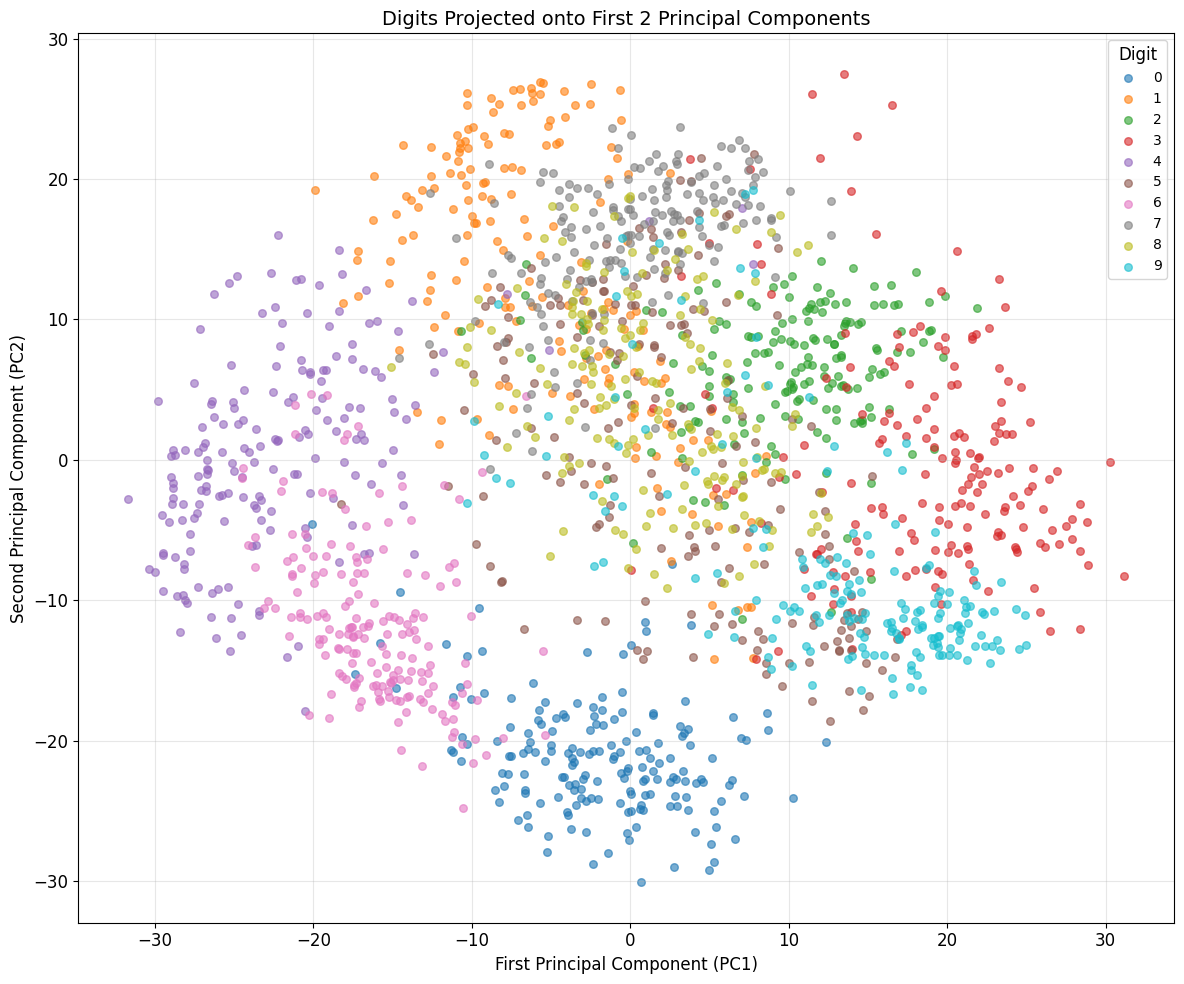

Observation: Similar digits cluster together in PCA space!
This shows PCA captures meaningful structure in the data.


In [15]:
# Visualize digits in 2D PCA space
fig, ax = plt.subplots(figsize=(12, 10))

# Create a color map for digits 0-9
colors = plt.cm.tab10(np.linspace(0, 1, 10))

for digit in range(10):
    mask = y == digit
    ax.scatter(X_projected[mask, 0], X_projected[mask, 1],
               c=[colors[digit]], label=str(digit), alpha=0.6, s=30)

ax.set_xlabel('First Principal Component (PC1)', fontsize=12)
ax.set_ylabel('Second Principal Component (PC2)', fontsize=12)
ax.set_title('Digits Projected onto First 2 Principal Components', fontsize=14)
ax.legend(title='Digit', loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Observation: Similar digits cluster together in PCA space!")
print("This shows PCA captures meaningful structure in the data.")

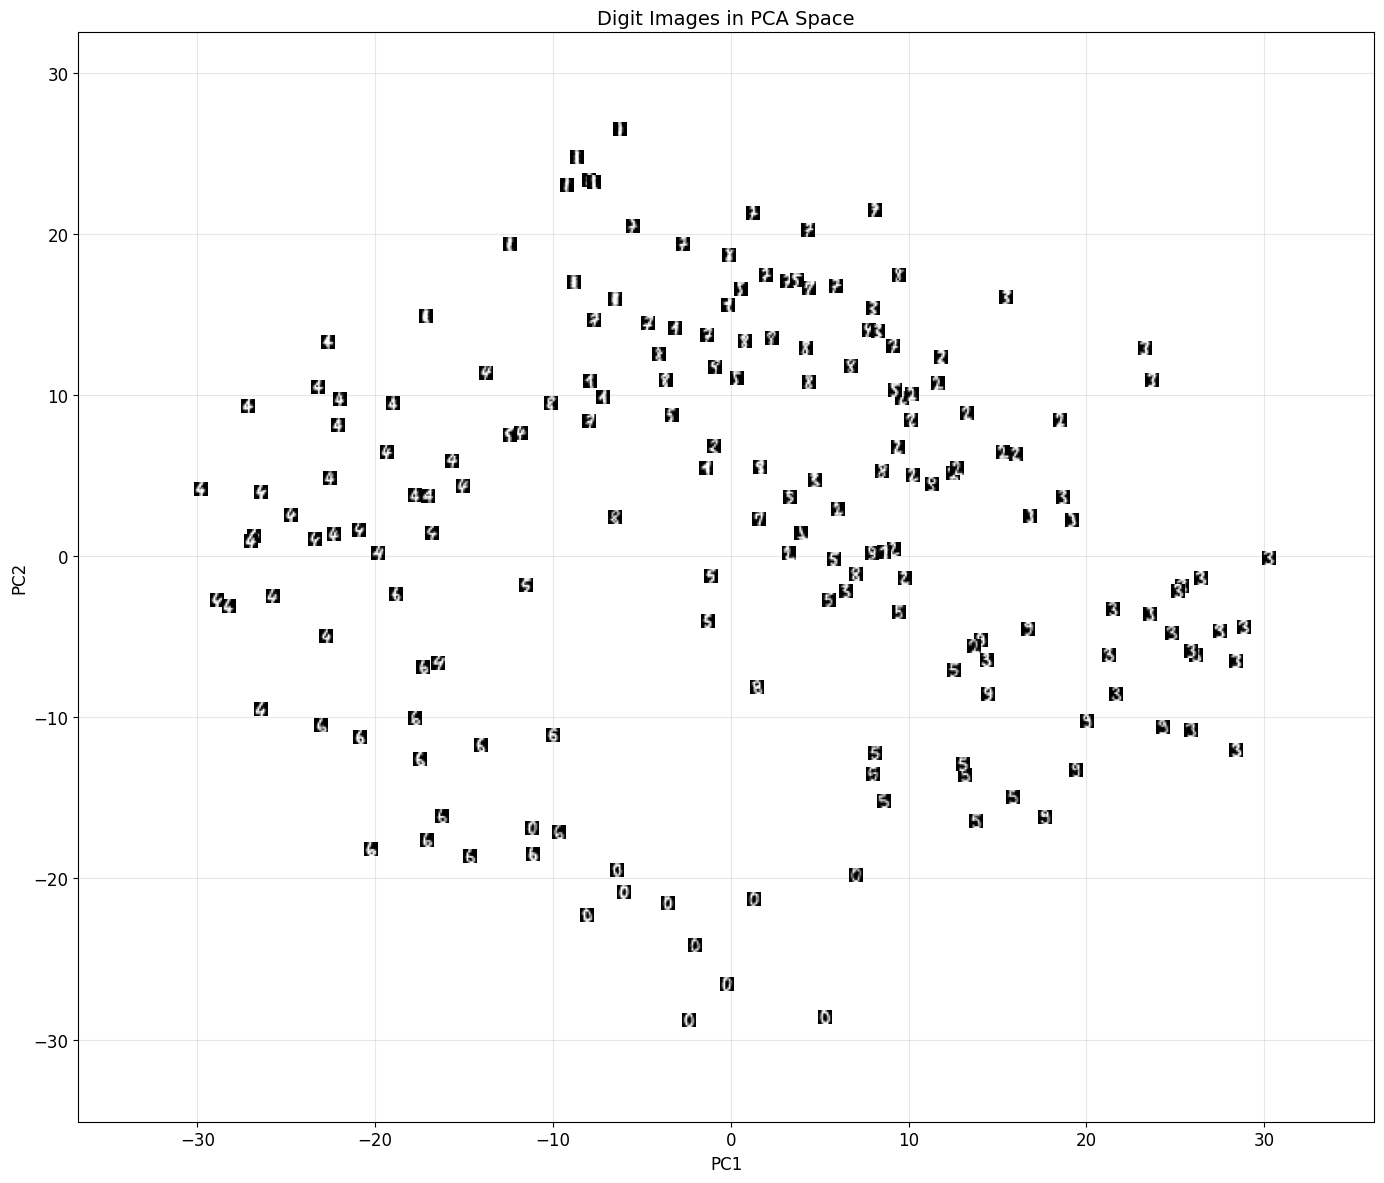

In [16]:
# Alternative visualization: show actual digit images at their PCA locations
fig, ax = plt.subplots(figsize=(14, 12))

# Plot a subset of digits as images
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Sample indices (take every 10th sample to avoid overcrowding)
sample_indices = np.arange(0, len(X), 10)

for idx in sample_indices:
    # Create a small image
    img = X[idx].reshape(8, 8)
    imagebox = OffsetImage(img, zoom=1.2, cmap='gray')
    ab = AnnotationBbox(imagebox, (X_projected[idx, 0], X_projected[idx, 1]),
                        frameon=False)
    ax.add_artist(ab)

ax.set_xlim(X_projected[:, 0].min() - 5, X_projected[:, 0].max() + 5)
ax.set_ylim(X_projected[:, 1].min() - 5, X_projected[:, 1].max() + 5)
ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.set_title('Digit Images in PCA Space', fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 6: Explained Variance

How much information do we retain when reducing dimensions? The **explained variance ratio** tells us what fraction of the total variance is captured by each principal component:

$$\text{Explained Variance Ratio}_i = \frac{\lambda_i}{\sum_{j=1}^{d} \lambda_j}$$

The **cumulative explained variance** shows how much total variance is captured by the first $k$ components.

In [17]:
# Compute explained variance ratios
total_variance = np.sum(eigenvalues_from_svd)
explained_variance_ratio = eigenvalues_from_svd / total_variance
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

print("Explained variance by component:")
print("-" * 45)
for i in range(10):
    print(f"  PC{i+1}: {explained_variance_ratio[i]*100:5.2f}% "
          f"(cumulative: {cumulative_variance_ratio[i]*100:5.2f}%)")

Explained variance by component:
---------------------------------------------
  PC1: 14.89% (cumulative: 14.89%)
  PC2: 13.62% (cumulative: 28.51%)
  PC3: 11.79% (cumulative: 40.30%)
  PC4:  8.41% (cumulative: 48.71%)
  PC5:  5.78% (cumulative: 54.50%)
  PC6:  4.92% (cumulative: 59.41%)
  PC7:  4.32% (cumulative: 63.73%)
  PC8:  3.66% (cumulative: 67.39%)
  PC9:  3.35% (cumulative: 70.74%)
  PC10:  3.08% (cumulative: 73.82%)


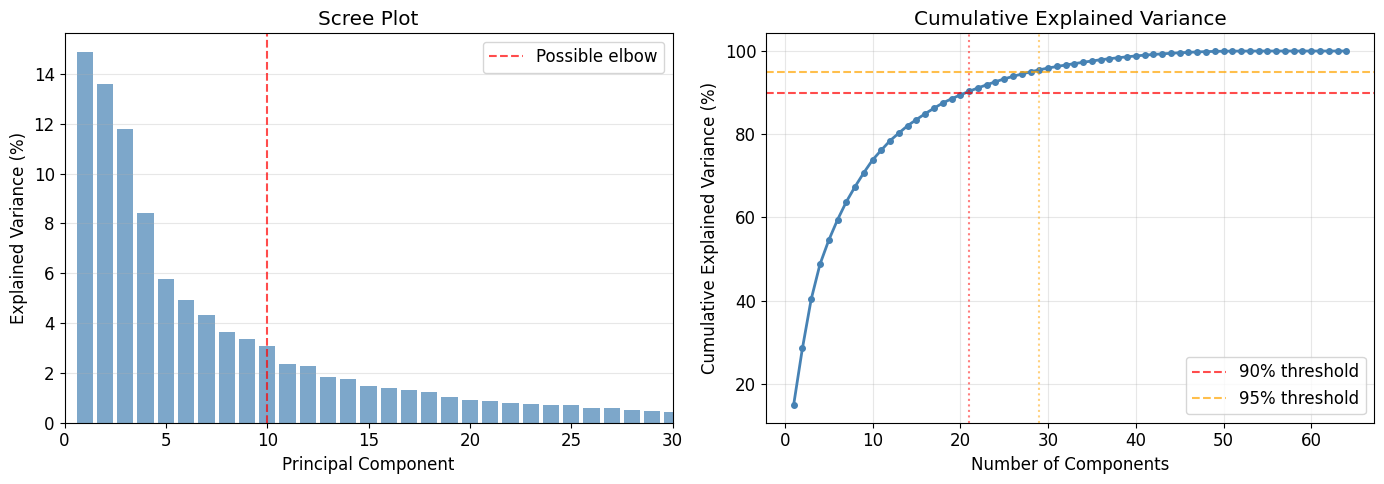


Components needed for 90% variance: 21
Components needed for 95% variance: 29
Original dimensions: 64 -> Reduced dimensions: 21 (for 90%)


In [18]:
# Scree plot and cumulative variance plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot (eigenvalue spectrum)
ax = axes[0]
ax.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio * 100,
       alpha=0.7, color='steelblue')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance (%)')
ax.set_title('Scree Plot')
ax.set_xlim(0, 30)
ax.grid(True, alpha=0.3, axis='y')

# Add elbow annotation
ax.axvline(x=10, color='red', linestyle='--', alpha=0.7, label='Possible elbow')
ax.legend()

# Cumulative variance plot
ax = axes[1]
ax.plot(range(1, len(cumulative_variance_ratio) + 1), cumulative_variance_ratio * 100,
        'o-', linewidth=2, markersize=4, color='steelblue')
ax.axhline(y=90, color='red', linestyle='--', alpha=0.7, label='90% threshold')
ax.axhline(y=95, color='orange', linestyle='--', alpha=0.7, label='95% threshold')

# Find number of components for 90% and 95% variance
n_90 = np.argmax(cumulative_variance_ratio >= 0.90) + 1
n_95 = np.argmax(cumulative_variance_ratio >= 0.95) + 1
ax.axvline(x=n_90, color='red', linestyle=':', alpha=0.5)
ax.axvline(x=n_95, color='orange', linestyle=':', alpha=0.5)

ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Explained Variance (%)')
ax.set_title('Cumulative Explained Variance')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nComponents needed for 90% variance: {n_90}")
print(f"Components needed for 95% variance: {n_95}")
print(f"Original dimensions: 64 -> Reduced dimensions: {n_90} (for 90%)")

## Step 7: Reconstruction

We can reconstruct the original data from the reduced representation:

$$X_{reconstructed} = X_{projected} \cdot V_k^T + \mu$$

The reconstruction quality depends on how many principal components we keep. More components = better reconstruction but less compression.

In [19]:
def reconstruct_from_pca(X_centered, components, mean, n_components):
    """
    Reconstruct data using the first n_components principal components.
    
    Parameters:
        X_centered: Centered data (n_samples, n_features)
        components: Principal components (n_components, n_features)
        mean: Original data mean (n_features,)
        n_components: Number of components to use
    
    Returns:
        X_reconstructed: Reconstructed data (n_samples, n_features)
    """
    # Project to lower dimension
    V_k = components[:n_components].T
    X_projected = X_centered @ V_k
    
    # Reconstruct
    X_reconstructed = X_projected @ V_k.T + mean
    
    return X_reconstructed

# Test reconstruction with different numbers of components
test_idx = 0
print(f"Reconstructing digit {y[test_idx]} with different numbers of components\n")

Reconstructing digit 0 with different numbers of components



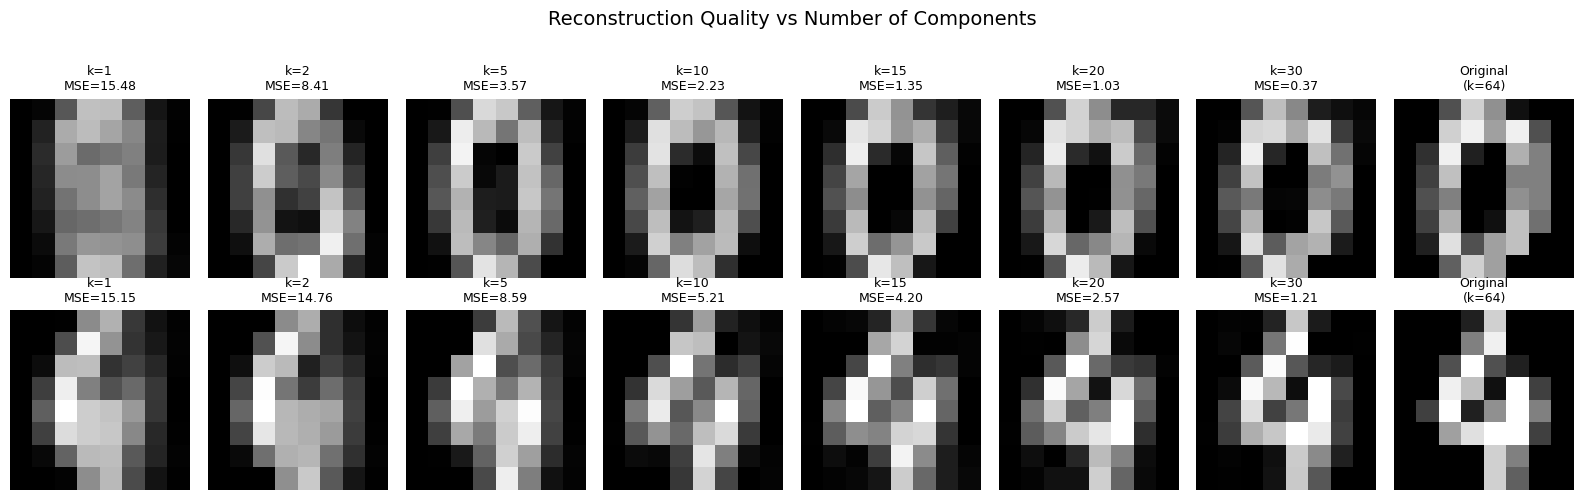

In [20]:
# Visualize reconstruction quality vs number of components
fig, axes = plt.subplots(2, 8, figsize=(16, 5))

n_components_list = [1, 2, 5, 10, 15, 20, 30, 64]
sample_indices = [0, 100]  # Two different digits

for row, idx in enumerate(sample_indices):
    for col, n_comp in enumerate(n_components_list):
        ax = axes[row, col]
        
        if n_comp == 64:
            # Full reconstruction (original)
            reconstructed = X[idx]
            title = f'Original\n(k=64)'
        else:
            reconstructed = reconstruct_from_pca(X_centered[idx:idx+1], 
                                                 components_svd, mean, n_comp)
            mse = np.mean((X[idx] - reconstructed.flatten())**2)
            title = f'k={n_comp}\nMSE={mse:.2f}'
        
        ax.imshow(reconstructed.reshape(8, 8), cmap='gray', vmin=0, vmax=16)
        ax.set_title(title, fontsize=9)
        ax.axis('off')
        
        if col == 0:
            ax.set_ylabel(f'Digit {y[idx]}', fontsize=12)

plt.suptitle('Reconstruction Quality vs Number of Components', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

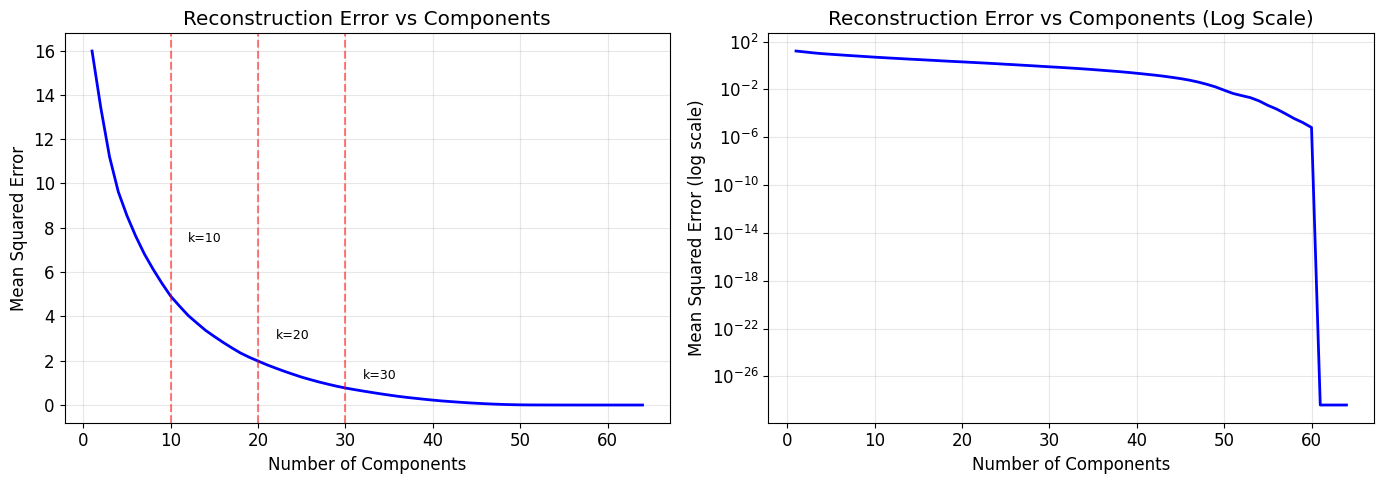

In [21]:
# Plot reconstruction error vs number of components
n_components_range = range(1, 65)
reconstruction_errors = []

for n_comp in n_components_range:
    X_reconstructed = reconstruct_from_pca(X_centered, components_svd, mean, n_comp)
    mse = np.mean((X - X_reconstructed)**2)
    reconstruction_errors.append(mse)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MSE vs components
ax = axes[0]
ax.plot(n_components_range, reconstruction_errors, 'b-', linewidth=2)
ax.set_xlabel('Number of Components')
ax.set_ylabel('Mean Squared Error')
ax.set_title('Reconstruction Error vs Components')
ax.grid(True, alpha=0.3)

# Mark some key points
for k in [10, 20, 30]:
    ax.axvline(x=k, color='red', linestyle='--', alpha=0.5)
    ax.annotate(f'k={k}', xy=(k, reconstruction_errors[k-1]), 
                xytext=(k+2, reconstruction_errors[k-1]*1.5),
                fontsize=9)

# Log scale
ax = axes[1]
ax.semilogy(n_components_range, reconstruction_errors, 'b-', linewidth=2)
ax.set_xlabel('Number of Components')
ax.set_ylabel('Mean Squared Error (log scale)')
ax.set_title('Reconstruction Error vs Components (Log Scale)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Complete PCA Class

Now let's put everything together into a complete, sklearn-compatible PCA class with `fit()`, `transform()`, and `inverse_transform()` methods.

In [22]:
class PCA:
    """
    Principal Component Analysis implementation from scratch.
    
    This implementation uses SVD for numerical stability and efficiency.
    
    Parameters
    ----------
    n_components : int, optional
        Number of components to keep. If None, keeps all components.
    
    Attributes
    ----------
    components_ : ndarray of shape (n_components, n_features)
        Principal axes in feature space (rows are eigenvectors)
    explained_variance_ : ndarray of shape (n_components,)
        Variance explained by each component
    explained_variance_ratio_ : ndarray of shape (n_components,)
        Percentage of variance explained by each component
    mean_ : ndarray of shape (n_features,)
        Per-feature mean from training data
    n_components_ : int
        Number of components
    n_features_ : int
        Number of features in training data
    n_samples_ : int
        Number of samples in training data
    """
    
    def __init__(self, n_components=None):
        self.n_components = n_components
        
        # Attributes set during fit
        self.components_ = None
        self.explained_variance_ = None
        self.explained_variance_ratio_ = None
        self.singular_values_ = None
        self.mean_ = None
        self.n_components_ = None
        self.n_features_ = None
        self.n_samples_ = None
    
    def fit(self, X):
        """
        Fit the PCA model with X.
        
        Parameters
        ----------
        X : array-like of shape (n_samples, n_features)
            Training data
        
        Returns
        -------
        self : object
            Returns self
        """
        X = np.asarray(X)
        self.n_samples_, self.n_features_ = X.shape
        
        # Determine number of components
        if self.n_components is None:
            self.n_components_ = min(self.n_samples_, self.n_features_)
        else:
            self.n_components_ = min(self.n_components, 
                                     self.n_samples_, 
                                     self.n_features_)
        
        # Step 1: Center the data
        self.mean_ = np.mean(X, axis=0)
        X_centered = X - self.mean_
        
        # Step 2: SVD
        U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
        
        # Step 3: Store components and explained variance
        self.components_ = Vt[:self.n_components_]
        self.singular_values_ = S[:self.n_components_]
        
        # Explained variance = sigma^2 / (n - 1)
        self.explained_variance_ = (S[:self.n_components_]**2) / (self.n_samples_ - 1)
        
        # Total variance
        total_var = np.sum(S**2) / (self.n_samples_ - 1)
        self.explained_variance_ratio_ = self.explained_variance_ / total_var
        
        return self
    
    def transform(self, X):
        """
        Apply dimensionality reduction to X.
        
        Parameters
        ----------
        X : array-like of shape (n_samples, n_features)
            Data to transform
        
        Returns
        -------
        X_transformed : ndarray of shape (n_samples, n_components)
            Transformed data
        """
        X = np.asarray(X)
        X_centered = X - self.mean_
        return X_centered @ self.components_.T
    
    def fit_transform(self, X):
        """
        Fit the model with X and apply dimensionality reduction.
        
        Parameters
        ----------
        X : array-like of shape (n_samples, n_features)
            Training data
        
        Returns
        -------
        X_transformed : ndarray of shape (n_samples, n_components)
            Transformed data
        """
        self.fit(X)
        return self.transform(X)
    
    def inverse_transform(self, X_transformed):
        """
        Transform data back to original space.
        
        Parameters
        ----------
        X_transformed : array-like of shape (n_samples, n_components)
            Data in transformed space
        
        Returns
        -------
        X_original : ndarray of shape (n_samples, n_features)
            Data in original space
        """
        X_transformed = np.asarray(X_transformed)
        return X_transformed @ self.components_ + self.mean_
    
    def get_covariance(self):
        """
        Compute data covariance with the generative model.
        
        Returns
        -------
        cov : ndarray of shape (n_features, n_features)
            Estimated covariance of data
        """
        return self.components_.T @ np.diag(self.explained_variance_) @ self.components_

In [23]:
# Test our PCA implementation
our_pca = PCA(n_components=2)
X_our = our_pca.fit_transform(X)

print("Our PCA Implementation:")
print(f"  Components shape: {our_pca.components_.shape}")
print(f"  Transformed data shape: {X_our.shape}")
print(f"  Explained variance ratio: {our_pca.explained_variance_ratio_}")

Our PCA Implementation:
  Components shape: (2, 64)
  Transformed data shape: (1797, 2)
  Explained variance ratio: [0.14890594 0.13618771]


## Validation Against sklearn

Let's verify our implementation matches sklearn's PCA exactly.

In [24]:
# Compare against sklearn's PCA
sklearn_pca = SklearnPCA(n_components=2)
X_sklearn = sklearn_pca.fit_transform(X)

print("Comparing Our PCA vs sklearn PCA:")
print("=" * 60)

# Compare explained variance ratios
print("\n1. Explained Variance Ratios:")
print(f"   Ours:    {our_pca.explained_variance_ratio_}")
print(f"   sklearn: {sklearn_pca.explained_variance_ratio_}")
print(f"   Match: {np.allclose(our_pca.explained_variance_ratio_, sklearn_pca.explained_variance_ratio_)}")

# Compare explained variance
print("\n2. Explained Variance:")
print(f"   Ours:    {our_pca.explained_variance_}")
print(f"   sklearn: {sklearn_pca.explained_variance_}")
print(f"   Match: {np.allclose(our_pca.explained_variance_, sklearn_pca.explained_variance_)}")

# Compare mean
print("\n3. Mean:")
print(f"   Match: {np.allclose(our_pca.mean_, sklearn_pca.mean_)}")

Comparing Our PCA vs sklearn PCA:

1. Explained Variance Ratios:
   Ours:    [0.14890594 0.13618771]
   sklearn: [0.14890594 0.13618771]
   Match: True

2. Explained Variance:
   Ours:    [179.0069301  163.71774688]
   sklearn: [179.0069301  163.71774688]
   Match: True

3. Mean:
   Match: True


In [25]:
# Compare components (accounting for sign ambiguity)
print("\n4. Components (accounting for sign ambiguity):")
for i in range(2):
    our_comp = our_pca.components_[i]
    sk_comp = sklearn_pca.components_[i]
    
    # Check both signs
    same_sign = np.allclose(our_comp, sk_comp)
    opposite_sign = np.allclose(our_comp, -sk_comp)
    
    if same_sign:
        print(f"   PC{i+1}: Match (same sign)")
    elif opposite_sign:
        print(f"   PC{i+1}: Match (opposite sign)")
    else:
        cos_sim = abs(np.dot(our_comp, sk_comp) / 
                      (np.linalg.norm(our_comp) * np.linalg.norm(sk_comp)))
        print(f"   PC{i+1}: Cosine similarity = {cos_sim:.10f}")


4. Components (accounting for sign ambiguity):
   PC1: Match (opposite sign)
   PC2: Match (same sign)


In [26]:
# Compare transformed data (accounting for sign flips in components)
print("\n5. Transformed Data:")

# Correct for potential sign flips
X_our_corrected = X_our.copy()
for i in range(2):
    if np.allclose(our_pca.components_[i], -sklearn_pca.components_[i]):
        X_our_corrected[:, i] *= -1

print(f"   Transformed data match: {np.allclose(X_our_corrected, X_sklearn)}")

# Compare reconstruction
print("\n6. Inverse Transform (Reconstruction):")
X_reconstructed_ours = our_pca.inverse_transform(X_our)
X_reconstructed_sklearn = sklearn_pca.inverse_transform(X_sklearn)
print(f"   Reconstruction match: {np.allclose(X_reconstructed_ours, X_reconstructed_sklearn)}")


5. Transformed Data:
   Transformed data match: True

6. Inverse Transform (Reconstruction):
   Reconstruction match: True


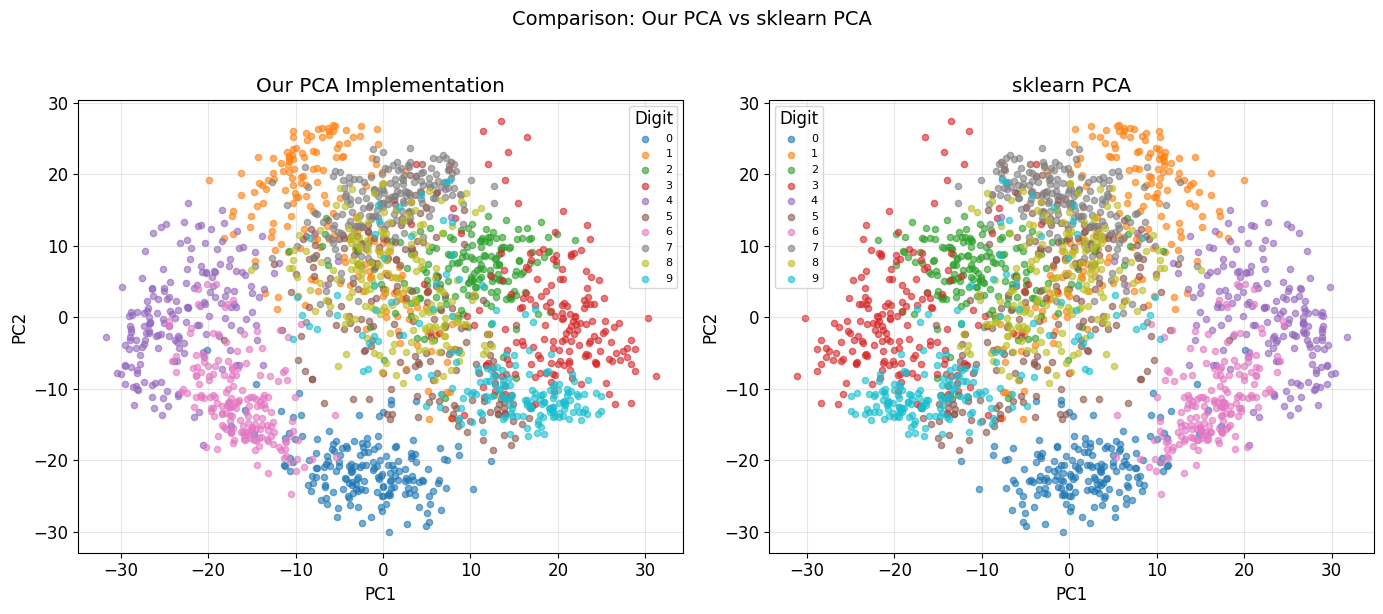

Note: Plots may be reflected due to sign ambiguity, but structure is identical


In [27]:
# Visual comparison of projections
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Our PCA
ax = axes[0]
for digit in range(10):
    mask = y == digit
    ax.scatter(X_our[mask, 0], X_our[mask, 1], 
               c=[plt.cm.tab10(digit)], label=str(digit), alpha=0.6, s=20)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('Our PCA Implementation')
ax.legend(title='Digit', fontsize=8, loc='best')
ax.grid(True, alpha=0.3)

# sklearn PCA
ax = axes[1]
for digit in range(10):
    mask = y == digit
    ax.scatter(X_sklearn[mask, 0], X_sklearn[mask, 1], 
               c=[plt.cm.tab10(digit)], label=str(digit), alpha=0.6, s=20)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('sklearn PCA')
ax.legend(title='Digit', fontsize=8, loc='best')
ax.grid(True, alpha=0.3)

plt.suptitle('Comparison: Our PCA vs sklearn PCA', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Note: Plots may be reflected due to sign ambiguity, but structure is identical")

## Eigendigits Visualization

The principal components can be visualized as "eigendigits" - they represent the directions of maximum variance in pixel space. Each eigendigit shows what combination of pixel intensities captures the most variation in the dataset.

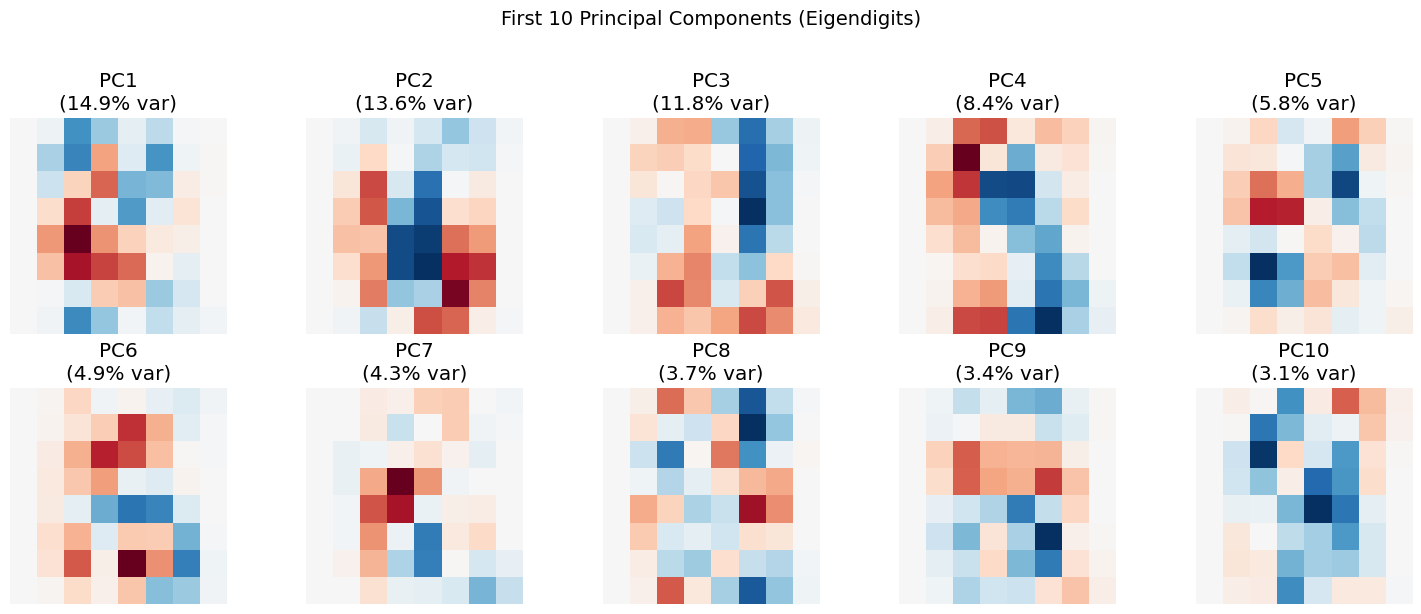

Interpretation:
- Red pixels: positive weights (high value increases this PC score)
- Blue pixels: negative weights (high value decreases this PC score)
- White pixels: near-zero weights (little contribution)


In [28]:
# Visualize the first 10 principal components (eigendigits)
pca_full = PCA(n_components=10)
pca_full.fit(X)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flatten()):
    eigendigit = pca_full.components_[i].reshape(8, 8)
    
    # Use diverging colormap centered at 0
    vmax = max(abs(eigendigit.min()), abs(eigendigit.max()))
    im = ax.imshow(eigendigit, cmap='RdBu', vmin=-vmax, vmax=vmax)
    
    var_pct = pca_full.explained_variance_ratio_[i] * 100
    ax.set_title(f'PC{i+1}\n({var_pct:.1f}% var)')
    ax.axis('off')

plt.suptitle('First 10 Principal Components (Eigendigits)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Red pixels: positive weights (high value increases this PC score)")
print("- Blue pixels: negative weights (high value decreases this PC score)")
print("- White pixels: near-zero weights (little contribution)")

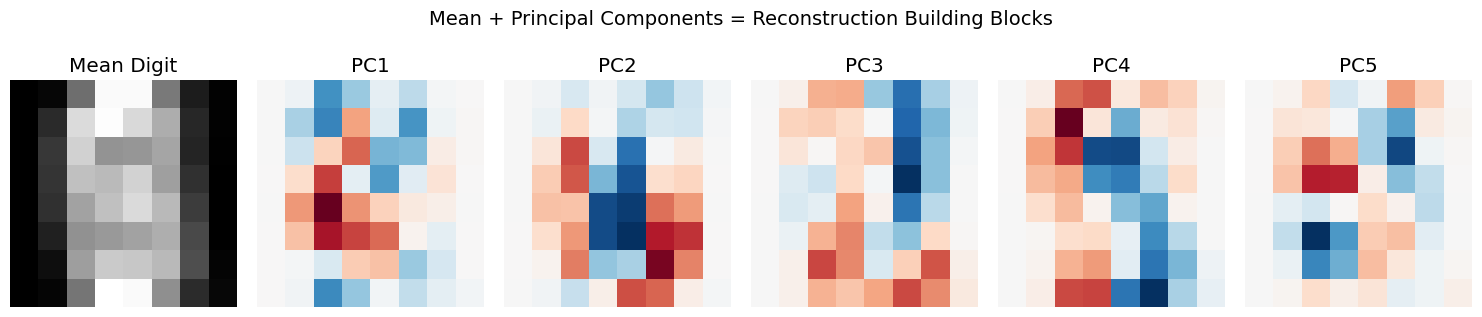

Any digit can be approximated as: Mean + c1*PC1 + c2*PC2 + c3*PC3 + ...


In [29]:
# Show the mean digit alongside eigendigits to understand reconstruction
fig, axes = plt.subplots(1, 6, figsize=(15, 3))

# Mean digit
ax = axes[0]
ax.imshow(pca_full.mean_.reshape(8, 8), cmap='gray')
ax.set_title('Mean Digit')
ax.axis('off')

# First 5 eigendigits
for i in range(5):
    ax = axes[i+1]
    eigendigit = pca_full.components_[i].reshape(8, 8)
    vmax = max(abs(eigendigit.min()), abs(eigendigit.max()))
    ax.imshow(eigendigit, cmap='RdBu', vmin=-vmax, vmax=vmax)
    ax.set_title(f'PC{i+1}')
    ax.axis('off')

plt.suptitle('Mean + Principal Components = Reconstruction Building Blocks', 
             fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

print("Any digit can be approximated as: Mean + c1*PC1 + c2*PC2 + c3*PC3 + ...")

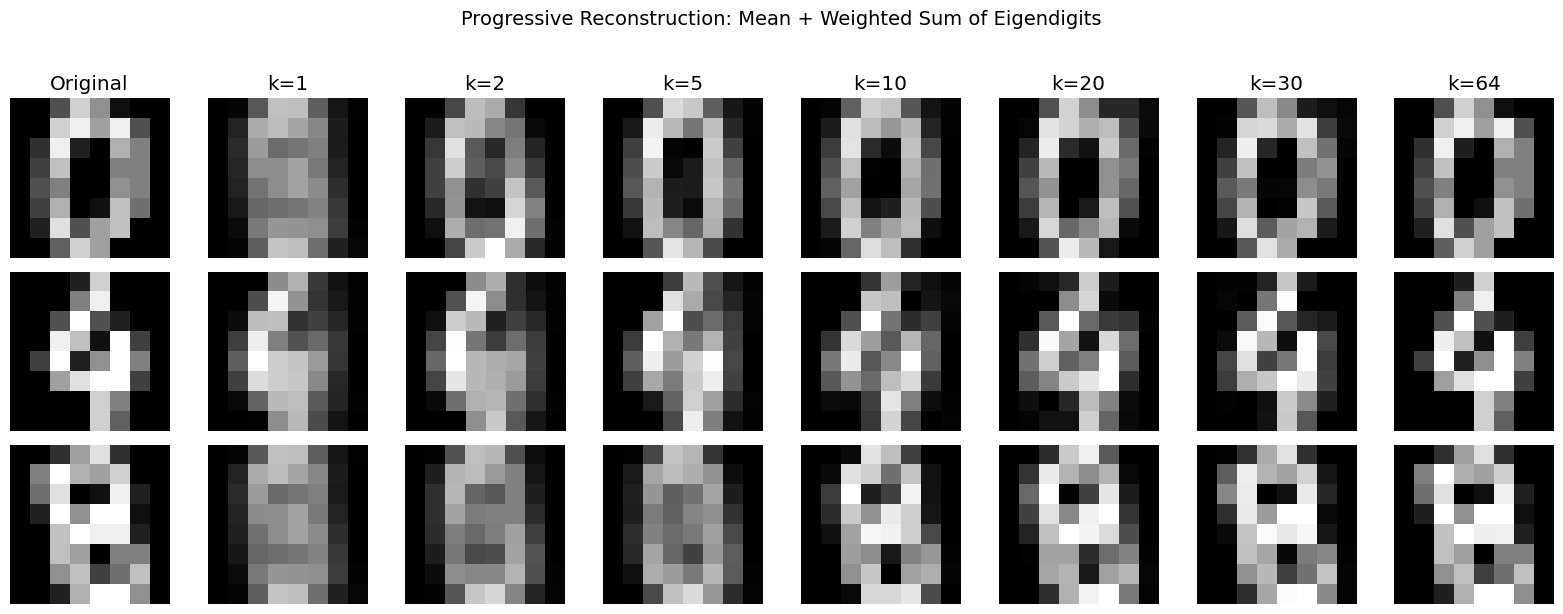

In [30]:
# Demonstrate progressive reconstruction using eigendigits
fig, axes = plt.subplots(3, 8, figsize=(16, 6))

test_indices = [0, 100, 500]  # Three different digits

for row, idx in enumerate(test_indices):
    # Original
    ax = axes[row, 0]
    ax.imshow(X[idx].reshape(8, 8), cmap='gray', vmin=0, vmax=16)
    ax.set_title('Original' if row == 0 else '')
    ax.axis('off')
    if row == 0:
        ax.set_ylabel(f'Digit {y[idx]}', fontsize=10)
    
    # Progressive reconstruction
    n_components_list = [1, 2, 5, 10, 20, 30, 64]
    for col, n_comp in enumerate(n_components_list):
        ax = axes[row, col + 1]
        
        pca_temp = PCA(n_components=n_comp)
        pca_temp.fit(X)
        X_proj = pca_temp.transform(X[idx:idx+1])
        X_recon = pca_temp.inverse_transform(X_proj)
        
        ax.imshow(X_recon.reshape(8, 8), cmap='gray', vmin=0, vmax=16)
        if row == 0:
            ax.set_title(f'k={n_comp}')
        ax.axis('off')

# Add row labels
for row, idx in enumerate(test_indices):
    axes[row, 0].set_ylabel(f'Digit {y[idx]}', fontsize=12)

plt.suptitle('Progressive Reconstruction: Mean + Weighted Sum of Eigendigits', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Summary

In this capstone project, we built PCA from scratch and explored its connections to fundamental linear algebra concepts.

### Key Insights

**1. PCA via Eigendecomposition:**
- Compute covariance matrix: $C = \frac{1}{n-1}X^T X$
- Find eigenvectors of $C$: these are the principal components
- Eigenvalues give variance explained by each component

**2. PCA via SVD (Preferred):**
- Directly decompose centered data: $X = U\Sigma V^T$
- Principal components are rows of $V^T$
- Relationship: $\lambda_i = \frac{\sigma_i^2}{n-1}$

**3. Why SVD is Preferred:**
- More numerically stable (avoids squaring the data)
- More efficient for high-dimensional data with few samples
- Directly gives the projected data: $X_{proj} = U\Sigma$

### The PCA Algorithm

```
1. Center: X_centered = X - mean(X)
2. SVD: U, S, Vt = svd(X_centered)
3. Components: V[:k] (first k rows of Vt)
4. Transform: X_proj = X_centered @ V[:k].T
5. Reconstruct: X_recon = X_proj @ V[:k] + mean
```

### Connections to Other Concepts

| Concept | PCA Connection |
|---------|----------------|
| Eigendecomposition | PCs are eigenvectors of covariance matrix |
| SVD | Most stable way to compute PCA |
| Matrix rank | k-component PCA gives rank-k approximation |
| Frobenius norm | PCA minimizes reconstruction error |
| Variance | Eigenvalues = variance along each PC |

### Practical Applications

- **Dimensionality reduction**: Compress data while preserving structure
- **Visualization**: Project high-dimensional data to 2D/3D
- **Noise reduction**: Discard low-variance components
- **Feature extraction**: PCs can be features for ML models
- **Data preprocessing**: Decorrelate features before modeling

---

*This completes the capstone project for the Mathematical Foundations module.*